## Projeto Integrador Parte B – Preparação dos Dados

Nomes: Lucas Souza Santos, Ali Ahmad, Leonardo Tonon

### Sobre a preparação e limpeza de dados

Nesta etapa é realizado o processo de preparação dos dados utilizados na análise exploratória apresentada na Parte A do projeto.

O objetivo desta etapa é garantir a qualidade dos dados antes de sua utilização em análises mais avançadas ou modelos de aprendizado de máquina. Para isso, são realizadas verificações relacionadas a:

- estrutura e tipos de variáveis
- presença de valores ausentes
- duplicatas
- inconsistências categóricas
- identificação de outliers

Além disso, são realizadas transformações e criação de novas variáveis que podem auxiliar em análises futuras.

In [16]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_theme(style="darkgrid")

csv_paths = ['/content/UCI_Credit_Card.csv','UCI_Credit_Card.csv','/workspaces/Projeto-integrador-de-Comunica-o-de-dados/UCI_Credit_Card.csv']
for p in csv_paths:
    if os.path.exists(p):
        df = pd.read_csv(p)
        break
else:
    raise FileNotFoundError('Arquivo UCI_Credit_Card.csv não encontrado nos caminhos previstos.')

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


### Estrutura do dataset e tipos de variáveis

Nesta etapa são analisadas as dimensões do dataset e os tipos de variáveis presentes.

A função `df.shape` permite identificar o número de linhas e colunas do dataset, enquanto `df.dtypes` apresenta o tipo de cada variável.

In [4]:
print('Shape:', df.shape)
print('\nTipos:')
print(df.dtypes)

Shape: (30000, 25)

Tipos:
ID                              int64
LIMIT_BAL                     float64
SEX                             int64
EDUCATION                       int64
MARRIAGE                        int64
AGE                             int64
PAY_0                           int64
PAY_2                           int64
PAY_3                           int64
PAY_4                           int64
PAY_5                           int64
PAY_6                           int64
BILL_AMT1                     float64
BILL_AMT2                     float64
BILL_AMT3                     float64
BILL_AMT4                     float64
BILL_AMT5                     float64
BILL_AMT6                     float64
PAY_AMT1                      float64
PAY_AMT2                      float64
PAY_AMT3                      float64
PAY_AMT4                      float64
PAY_AMT5                      float64
PAY_AMT6                      float64
default.payment.next.month      int64
dtype: object


### Verificação de valores ausentes

A presença de valores ausentes pode comprometer análises estatísticas e modelos de aprendizado de máquina.

Para identificar possíveis valores faltantes foi utilizado o método `df.isnull().sum()`, que retorna a quantidade de valores nulos em cada coluna do dataset.

Caso fossem identificados valores ausentes, algumas estratégias possíveis de tratamento seriam:

- remoção das linhas com dados incompletos
- substituição pela média ou mediana
- aplicação de técnicas de imputação de dados

In [5]:
print(df.isnull().sum())
print('\nTotal de valores ausentes:', df.isnull().sum().sum())

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

Total de valores ausentes: 0


### Verificação de registros duplicados

A presença de registros duplicados pode distorcer análises estatísticas e gerar vieses em modelos preditivos.

Para identificar possíveis duplicatas foi utilizado o método `df.duplicated()`, que verifica se existem registros repetidos no dataset.

In [6]:
print('Linhas duplicadas:', df.duplicated().sum())

Linhas duplicadas: 0


### Análise das variáveis categóricas

Nesta etapa são analisadas as distribuições das principais variáveis categóricas do dataset, como sexo, escolaridade e estado civil.

A análise das contagens permite identificar possíveis inconsistências, categorias raras ou valores inesperados nos dados.

In [7]:
for c in ['SEX','EDUCATION','MARRIAGE']:
    if c in df.columns:
        print(f"\n{c}:\n", df[c].value_counts(dropna=False))


SEX:
 SEX
2    18112
1    11888
Name: count, dtype: int64

EDUCATION:
 EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64

MARRIAGE:
 MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64


### Criação de faixas etárias

Para facilitar a análise demográfica dos clientes, foi criada uma nova variável chamada **AGE_GROUP**, que agrupa a idade dos clientes em faixas etárias.

Essa transformação permite realizar análises comparativas entre diferentes grupos de idade.

In [8]:
if 'AGE' in df.columns:
    bins = [0,20,30,40,50,60,70,120]
    labels = ['<20','20-29','30-39','40-49','50-59','60-69','70+']
    df['AGE_GROUP'] = pd.cut(df['AGE'], bins=bins, labels=labels, right=False)
    print(df['AGE_GROUP'].value_counts())

AGE_GROUP
30-39    11238
20-29     9618
40-49     6464
50-59     2341
60-69      314
70+         25
<20          0
Name: count, dtype: int64


### Estatísticas descritivas das variáveis numéricas

As estatísticas descritivas permitem compreender o comportamento geral das variáveis numéricas presentes no dataset.

Foram analisadas métricas como:

- média
- mediana
- desvio padrão
- valores mínimos e máximos
- quartis

Essas informações ajudam a identificar padrões, dispersão dos dados e possíveis anomalias.

In [9]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
describe = df[num_cols].describe().T
if 'median' not in describe.columns:
    describe['median'] = df[num_cols].median()
display(describe[['count','mean','median','std','min','25%','50%','75%','max']])

,count,mean,median,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,15000.5,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,140000.0,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,2.0,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,2.0,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,2.0,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,34.0,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,0.0,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,0.0,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,0.0,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,0.0,1.169139,-2.0,-1.00,0.0,0.00,8.0


### Análise de correlação entre variáveis

Para analisar relações entre variáveis numéricas foi utilizado um **heatmap de correlação**.

Esse tipo de visualização permite identificar variáveis que apresentam comportamento semelhante ou relações estatísticas relevantes.

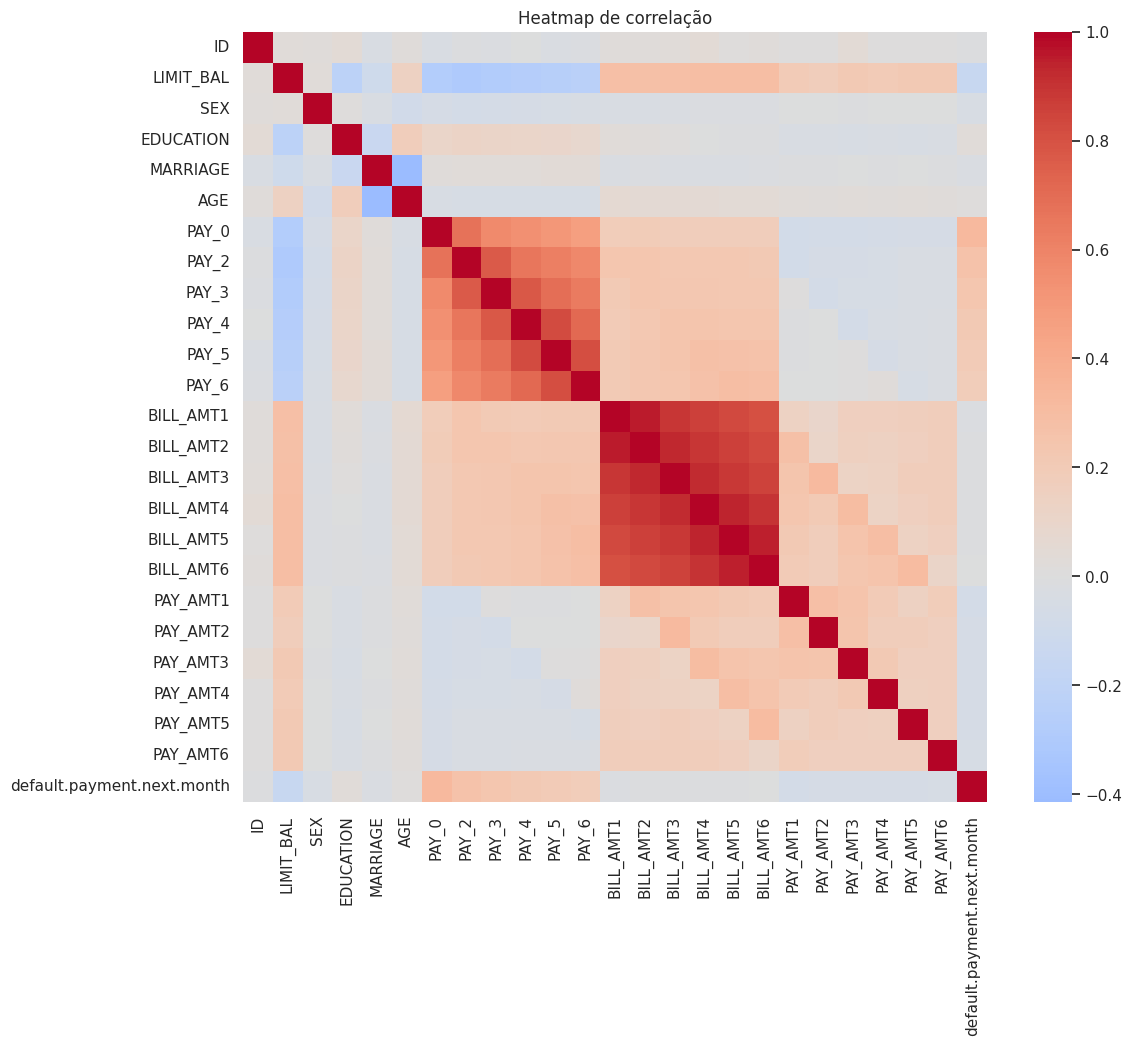

In [10]:
corr = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Heatmap de correlação')
plt.show()

### Identificação de outliers

Outliers são valores extremos que podem influenciar significativamente análises estatísticas.

Para identificar esses valores foi utilizado o método **IQR (Intervalo Interquartil)**, que considera valores muito acima ou abaixo da distribuição normal dos dados.

In [11]:
fin_cols = [c for c in ['LIMIT_BAL'] + [f'BILL_AMT{i}' for i in range(1,7)] + [f'PAY_AMT{i}' for i in range(1,7)] if c in df.columns]
outliers = {}
for c in fin_cols:
    Q1 = df[c].quantile(0.25)
    Q3 = df[c].quantile(0.75)
    IQR = Q3 - Q1
    low = Q1 - 1.5 * IQR
    high = Q3 + 1.5 * IQR
    out_count = df[(df[c] < low) | (df[c] > high)].shape[0]
    outliers[c] = out_count
print('Outliers (IQR) por coluna:')
for k,v in outliers.items():
    print(f'{k}: {v} ({v/len(df):.2%})')

Outliers (IQR) por coluna:
LIMIT_BAL: 167 (0.56%)
BILL_AMT1: 2400 (8.00%)
BILL_AMT2: 2395 (7.98%)
BILL_AMT3: 2469 (8.23%)
BILL_AMT4: 2622 (8.74%)
BILL_AMT5: 2725 (9.08%)
BILL_AMT6: 2693 (8.98%)
PAY_AMT1: 2745 (9.15%)
PAY_AMT2: 2714 (9.05%)
PAY_AMT3: 2598 (8.66%)
PAY_AMT4: 2994 (9.98%)
PAY_AMT5: 2945 (9.82%)
PAY_AMT6: 2958 (9.86%)


### Transformação e engenharia de atributos

Nesta etapa são realizadas transformações nas variáveis existentes e criação de novas variáveis que podem auxiliar em análises futuras ou modelos preditivos.

A engenharia de atributos é uma etapa importante da preparação de dados, pois permite extrair novas informações relevantes a partir das variáveis originais.

In [12]:
df_prep = df.copy()
if 'EDUCATION' in df_prep.columns:
    df_prep['EDUCATION'] = df_prep['EDUCATION'].replace([0,4,5,6],'Outros')
if 'MARRIAGE' in df_prep.columns:
    df_prep['MARRIAGE'] = df_prep['MARRIAGE'].replace({0:'Desconhecido/Outros'})
print('EDUCATION:')
if 'EDUCATION' in df_prep.columns:
    print(df_prep['EDUCATION'].value_counts())
print('\nMARRIAGE:')
if 'MARRIAGE' in df_prep.columns:
    print(df_prep['MARRIAGE'].value_counts())

EDUCATION:
EDUCATION
2         14030
1         10585
3          4917
Outros      468
Name: count, dtype: int64

MARRIAGE:
MARRIAGE
2                      15964
1                      13659
3                        323
Desconhecido/Outros       54
Name: count, dtype: int64


In [18]:
bill_cols = [c for c in df_prep.columns if c.startswith('BILL_AMT')]
if 'LIMIT_BAL' in df_prep.columns and bill_cols:
    df_prep['MAX_BILL_AMT'] = df_prep[bill_cols].max(axis=1)
    df_prep['UTILIZATION_RATE'] = df_prep['MAX_BILL_AMT'] / df_prep['LIMIT_BAL'].replace(0, np.nan)
    df_prep['UTILIZATION_RATE'].replace([np.inf, -np.inf], 0, inplace=True)
    df_prep['UTILIZATION_RATE'].fillna(0, inplace=True)
    display(df_prep['UTILIZATION_RATE'].describe())
else:
    print('UTILIZATION_RATE não criada: LIMIT_BAL ou BILL_AMT ausente')

/tmp/ipykernel_392/3214457000.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_prep['UTILIZATION_RATE'].replace([np.inf, -np.inf], 0, inplace=True)
/tmp/ipykernel_392/3214457000.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value,

,UTILIZATION_RATE
count,30000.000000
mean,0.494965
std,0.433046
min,-0.100000
25%,0.070636
50%,0.430702
75%,0.923246
max,10.688575


In [14]:
pay_cols = [c for c in df_prep.columns if c.startswith('PAY_')]
if pay_cols:
    def avg_positive(row):
        vals = [row[c] for c in pay_cols if pd.notna(row[c])]
        positives = [v for v in vals if v > 0]
        return np.mean(positives) if positives else 0
    df_prep['AVG_PAY_STATUS'] = df_prep.apply(avg_positive, axis=1)
    display(df_prep['AVG_PAY_STATUS'].describe())
else:
    print('AVG_PAY_STATUS não criada: colunas PAY_* ausentes')

,AVG_PAY_STATUS
count,30000.000000
mean,5652.221691
std,10987.096735
min,0.000000
25%,1176.000000
50%,2515.770833
75%,5850.000000
max,627344.333333


### Salvamento do conjunto de dados preparado

Após a etapa de limpeza e transformação dos dados, o dataset preparado é salvo em um novo arquivo.

Isso permite preservar os dados originais e utilizar a versão preparada em etapas posteriores do projeto, como modelagem preditiva ou análises adicionais.

In [15]:
out_dir = '/workspaces/Projeto-integrador-de-Comunica-o-de-dados/data/processed'
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir,'UCI_Credit_Card_prepared.csv')
df_prep.to_csv(out_path, index=False)
print('Arquivo salvo:', out_path)

Arquivo salvo: /workspaces/Projeto-integrador-de-Comunica-o-de-dados/data/processed/UCI_Credit_Card_prepared.csv
